## Minimal example of calculating NPQ-corrected fluorescence from float data

This notebook defines the function for calculating NPQ-corrected fluorescence from uncalibrated float `CHLA_FLUORESCENCE`, and applies it to some data from float ID 5906765 in the equatorial Pacific.

### Import packages, define function, read in float data

In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt

In [6]:
from scripts.npqc import calculate_NPQ_fluo

In [7]:
ds_fl = xr.open_dataset('data/2903884_Sprof.nc')

### Calculate and plot for the first 10 profiles

In [8]:
ds = ds_fl.isel(N_PROF=slice(10))   
ds = calculate_NPQ_fluo(ds)

In [9]:
ds

<xarray.Dataset> Size: 7MB
Dimensions:                            (N_PROF: 10, N_PARAM: 14, N_CALIB: 1,
                                        N_LEVELS: 1585)
Coordinates:
  * N_PROF                             (N_PROF) int64 80B 0 1 2 3 4 5 6 7 8 9
Dimensions without coordinates: N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/130)
    DATA_TYPE                          object 8B ...
    FORMAT_VERSION                     object 8B ...
    HANDBOOK_VERSION                   object 8B ...
    REFERENCE_DATE_TIME                object 8B ...
    DATE_CREATION                      object 8B ...
    DATE_UPDATE                        object 8B ...
    ...                                 ...
    NITRATE_dPRES                      (N_PROF, N_LEVELS) float32 63kB ...
    NITRATE_ADJUSTED                   (N_PROF, N_LEVELS) float32 63kB ...
    NITRATE_ADJUSTED_QC                (N_PROF, N_LEVELS) object 127kB ...
    NITRATE_ADJUSTED_ERROR             (N_PROF, N_LEVELS) float32 63kB ...
    fluo_smooth                        (N_PROF, N_LEVELS) float32 63kB 1.102 ...
    fluo_npqc                          (N_PROF, N_LEVELS) float32 63kB 1.396 ...
Attributes:
    title:                Argo float vertical profile
    institution:          AOML
    source:               Argo float
    history:              2026-08-17T23:02:44Z creation (software version 1.2...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.22 (version 12.05.2025 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

(250.0, 0.0)

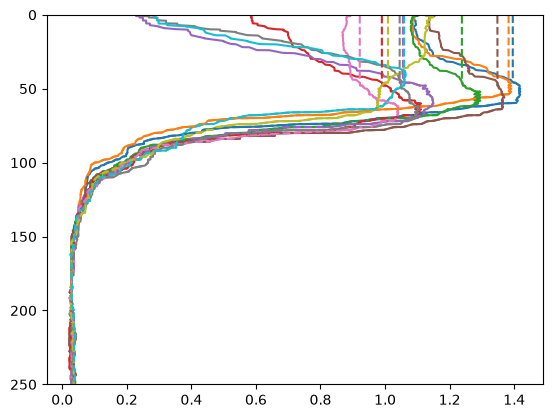

In [7]:
fig, ax = plt.subplots()
plt.plot(fl_smooth.T, ds['PRES_ADJUSTED'].T, '-')
plt.plot(fl_npq.T, ds['PRES_ADJUSTED'].T, '--')
# match line colors
h1 = ax.get_children()
for hh in range(11, 20):
    h1[hh].set_color(h1[hh-10].get_color())
ax.set_ylim([250, 0])

In [9]:
from scripts.fit_NPQ import NPQ_func